<p style ="text-align:center">
    <img src="http://epecora.com.br/DataFiles/BannerUFPR.png" width="700" alt="PPGOLD/PPGMNE Python:INTRO"  />
</p>


# Comparando duas médias: os dois cenários realmente são diferentes?

### MQ2 - Métodos Quantitativos 2 | Liga Data Science / UFPR

---

Quando comparamos dois cenários (um processo atual vs. uma mudança proposta, dois fornecedores, duas
filiais...), quase sempre olhamos a média de cada um e vemos números diferentes. A pergunta que
importa para a decisão é outra: **essa diferença é real, ou pode ser só ruído da amostra que
coletamos?**

Este notebook responde a essa pergunta usando testes estatísticos prontos (do `scipy` e do
`statsmodels`) e, principalmente, **traduz o resultado em uma recomendação de negócio**. Não é
necessário entender as fórmulas por trás dos testes para usar este material - o foco é: como ler o
resultado e o que fazer com ele.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

NAVY, AMBER, TEAL, CORAL, GRAY = "#1A2744", "#E8A020", "#2E8B8B", "#D9534F", "#8A94A6"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "axes.edgecolor": GRAY,
    "axes.labelcolor": NAVY, "text.color": NAVY, "xtick.color": NAVY, "ytick.color": NAVY,
    "font.size": 11, "axes.titlesize": 13, "axes.titleweight": "bold",
})

rng = np.random.default_rng(42)
print("Prontos para começar.")


Prontos para começar.


## 1. O cenário

Uma empresa testou uma **nova política de atendimento** (Cenário B) contra a política **atual**
(Cenário A) e mediu o tempo de atendimento (em minutos) de uma amostra de clientes em cada uma.

A pergunta do gestor: *"A nova política realmente mudou o tempo médio de atendimento, ou a diferença
que vejo nos números é só variação normal da amostra?"*


In [2]:
n_A, n_B = 35, 28
cenario_A = rng.normal(12.0, 3.0, n_A)   # política atual
cenario_B = rng.normal(13.2, 5.4, n_B)   # política proposta

resumo = pd.DataFrame({
    "Tamanho da amostra": [n_A, n_B],
    "Tempo médio (min)":  [cenario_A.mean(), cenario_B.mean()],
    "Desvio-padrão":      [cenario_A.std(ddof=1), cenario_B.std(ddof=1)],
}, index=["Cenário A (atual)", "Cenário B (proposta)"])

resumo.round(2)


,Tamanho da amostra,Tempo médio (min),Desvio-padrão
Cenário A (atual),35,12.13,2.49
Cenário B (proposta),28,13.30,4.17


/tmp/ipykernel_3806/945120387.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot([cenario_A, cenario_B], labels=["A (atual)", "B (proposta)"],


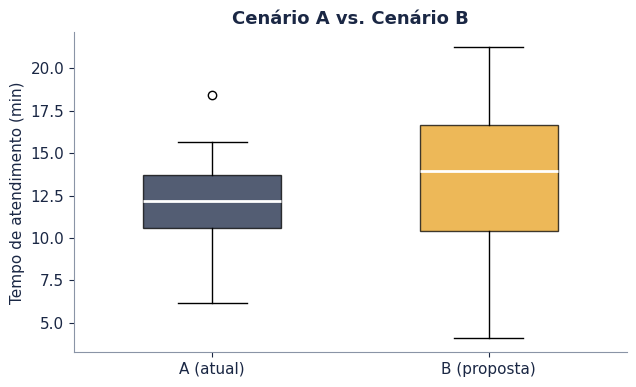

In [3]:
fig, ax = plt.subplots(figsize=(6.5, 4))
bp = ax.boxplot([cenario_A, cenario_B], labels=["A (atual)", "B (proposta)"],
                 patch_artist=True, widths=0.5)
for patch, cor in zip(bp["boxes"], [NAVY, AMBER]):
    patch.set_facecolor(cor); patch.set_alpha(0.75)
for med in bp["medians"]:
    med.set_color("white"); med.set_linewidth(2)

ax.set_ylabel("Tempo de atendimento (min)")
ax.set_title("Cenário A vs. Cenário B")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout(); plt.show()


**Leitura rápida:** a média do Cenário B parece um pouco maior, mas as caixas se sobrepõem bastante
e o Cenário B tem uma variação bem maior (caixa mais alta). Isso já é um sinal visual de que a resposta
não é óbvia - é exatamente para isso que servem os testes a seguir.


## 2. Qual teste usar? (guia rápido)

| Situação | Teste indicado |
|---|---|
| Amostra grande e/ou variância populacional já é bem conhecida (caso raro na prática) | **Teste Z** |
| Amostra normal, e os dois grupos têm **variação parecida** entre si | **Teste T (variâncias iguais)** |
| Amostra normal, mas os dois grupos têm **variação bem diferente** entre si (como no nosso exemplo) | **Teste T de Welch (variâncias diferentes)** |

Na dúvida entre as duas versões do teste T: **o teste de Welch é a opção mais segura**, pois não exige
que os dois grupos tenham a mesma variação - e por isso é o padrão em vários softwares estatísticos
(R, por exemplo, usa Welch por padrão).

Como saber se a variação é "parecida" ou "bem diferente"? Comparamos os desvios-padrão dos dois grupos
com um teste de igualdade de variâncias (Levene), pronto no `scipy`.


In [4]:
levene_stat, levene_p = stats.levene(cenario_A, cenario_B)

print(f"Teste de Levene (igualdade de variâncias): valor-p = {levene_p:.3f}")
if levene_p < 0.05:
    print(">> As variâncias dos dois grupos são estatisticamente diferentes.")
    print(">> Recomendação: usar o teste T de Welch.")
else:
    print(">> Não há evidência de que as variâncias sejam diferentes.")
    print(">> Tanto faz usar o teste T pooled ou o de Welch - os resultados devem ser parecidos.")


Teste de Levene (igualdade de variâncias): valor-p = 0.012
>> As variâncias dos dois grupos são estatisticamente diferentes.
>> Recomendação: usar o teste T de Welch.


## 3. Rodando os testes (métodos prontos)

Usamos diretamente as funções do `scipy.stats` e do `statsmodels` — nenhuma fórmula manual é
necessária. Cada teste devolve três informações-chave:

- **valor-p**: a chance de observarmos uma diferença deste tamanho (ou maior) *se, na realidade, as
  médias fossem iguais*. Valor-p baixo (convencionalmente **< 0,05**) é evidência de que a diferença é
  real.
- **intervalo de confiança (IC) de 95%** para a diferença entre as médias: a faixa de valores
  plausíveis para "quanto o Cenário B é maior ou menor que o A". **Se o intervalo inclui o zero**, o
  teste não encontrou diferença estatisticamente confiável.
- **diferença observada**: a diferença de médias calculada diretamente nos dados.


In [9]:
alpha = 0.05
cm = CompareMeans(DescrStatsW(cenario_B), DescrStatsW(cenario_A))   # B - A

resultados = {}

# --- Teste Z ---------------------------------------------------
z_stat, z_p = cm.ztest_ind()
z_ic = cm.zconfint_diff()
resultados["Teste Z"] = dict(estatistica=z_stat, valor_p=z_p, ic=z_ic)

# --- Teste T, variâncias iguais (pooled) ------------------------
t_stat_p, t_p_p, gl_p = cm.ttest_ind(usevar="pooled")
t_ic_p = cm.tconfint_diff(usevar="pooled")
resultados["Teste T (variâncias iguais)"] = dict(estatistica=t_stat_p, valor_p=t_p_p, ic=t_ic_p)

# --- Teste T de Welch, variâncias diferentes --------------------
t_stat_w, t_p_w, gl_w = cm.ttest_ind(usevar="unequal")
t_ic_w = cm.tconfint_diff(usevar="unequal")
resultados["Teste T de Welch (variâncias diferentes)"] = dict(estatistica=t_stat_w, valor_p=t_p_w, ic=t_ic_w)

tabela = pd.DataFrame(resultados).T
tabela["Média"] = tabela["ic"].apply(lambda x: (x[0]+x[1])/2)
tabela["IC 95% inferior"] = tabela["ic"].apply(lambda x: x[0])
tabela["IC 95% superior"] = tabela["ic"].apply(lambda x: x[1])
tabela = tabela.drop(columns="ic")
tabela["Conclusão"] = tabela["valor_p"].apply(
    lambda p: "Diferença estatisticamente significativa" if p < alpha else "Sem evidência de diferença"
)

tabela.round(3)


,estatistica,valor_p,Média,IC 95% inferior,IC 95% superior,Conclusão
Teste Z,1.383852,0.166404,1.172,-0.488,2.831,Sem evidência de diferença
Teste T (variâncias iguais),1.383852,0.171447,1.172,-0.521,2.864,Sem evidência de diferença
Teste T de Welch (variâncias diferentes),1.311825,0.196712,1.172,-0.631,2.974,Sem evidência de diferença


### Como ler a tabela acima

A diferença observada (Cenário B − Cenário A) é positiva em todos os testes: em média, a amostra do
Cenário B teve tempos maiores. A pergunta é se essa diferença é **estatisticamente confiável** ou se
pode ser só sorte de amostragem.

## 4. Gráfico 1 — Intervalos de confiança da diferença

Cada barra mostra a faixa plausível para "quanto o Cenário B é maior que o A", segundo cada teste.
A linha vertical em zero é o ponto de "nenhuma diferença". **Se a barra cruza essa linha, o teste não
encontrou uma diferença confiável.**


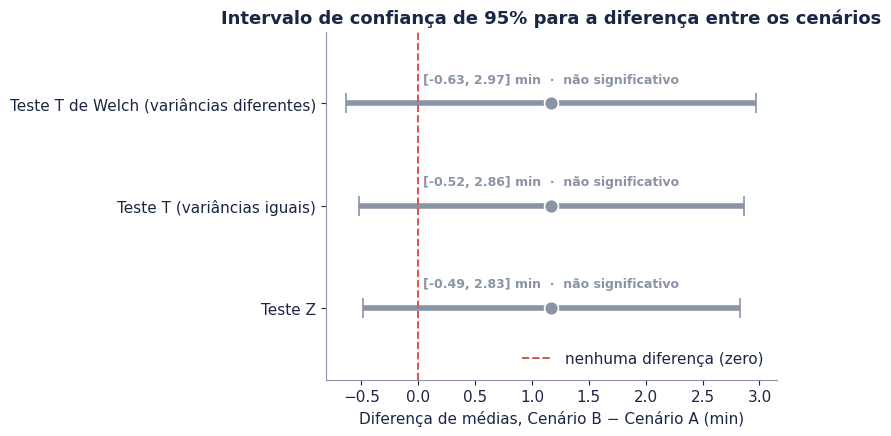

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
nomes = list(resultados.keys())
cores = [TEAL, NAVY, AMBER]

for i, (nome, cor) in enumerate(zip(nomes, cores)):
    lo, hi = resultados[nome]["ic"]
    centro = (lo + hi) / 2
    margem = (hi - lo) / 2
    significativo = resultados[nome]["valor_p"] < alpha
    cor_barra = cor if significativo else GRAY

    ax.errorbar(centro, i, xerr=margem, fmt="o", color=cor_barra, ecolor=cor_barra,
                elinewidth=4, capsize=7, markersize=10, markeredgecolor="white", markeredgewidth=1.2)
    rotulo = "significativo" if significativo else "não significativo"
    ax.annotate(f"[{lo:.2f}, {hi:.2f}] min  ·  {rotulo}",
                xy=(centro, i), xytext=(0, 15), textcoords="offset points",
                ha="center", fontsize=9, color=cor_barra, fontweight="bold")

ax.axvline(0, color=CORAL, linestyle="--", linewidth=1.4, label="nenhuma diferença (zero)")
ax.set_yticks(range(len(nomes))); ax.set_yticklabels(nomes)
ax.set_xlabel("Diferença de médias, Cenário B − Cenário A (min)")
ax.set_title("Intervalo de confiança de 95% para a diferença entre os cenários")
ax.legend(loc="lower right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(-0.7, len(nomes) - 0.3)
plt.tight_layout(); plt.show()


## 5. Conclusão e recomendação

Juntando os resultados:

- O teste de Levene indicou que **as variações dos dois cenários são diferentes**, então o teste mais
  apropriado aqui é o **T de Welch**.
- Nos três testes, o intervalo de confiança da diferença **inclui o zero** e o valor-p ficou **acima de
  0,05**.

**Recomendação para o gestor:** com o tamanho de amostra coletado, não há evidência estatística
suficiente de que a nova política (Cenário B) mude o tempo médio de atendimento. Isso não quer dizer
que a política não tenha efeito nenhum — pode ser que o efeito exista mas seja pequeno demais para essa
amostra detectar. Antes de decidir, vale considerar:

- **aumentar o tamanho da amostra**, o que estreita os intervalos de confiança e dá mais poder para
  detectar diferenças menores;
- olhar se há **razões operacionais** (custo, satisfação do cliente) para adotar o Cenário B mesmo sem
  diferença estatística no tempo médio;
- lembrar que "sem diferença estatisticamente significativa" **não é o mesmo que** "provado que são
  iguais" — apenas significa que os dados atuais não são conclusivos.

> **Dica prática:** troque `cenario_A` e `cenario_B` pelos seus próprios dados (uma lista/array de
> números) e rode o notebook novamente — a tabela, os gráficos e a recomendação se atualizam sozinhos.


## Fique Conectado

- [![YouTube](https://img.icons8.com/?size=40&id=19318&format=png&color=000000)](https://www.youtube.com/@LigaDataScience/videos)  
  Explore nossos vídeos educacionais e webinars sobre ciência de dados, machine learning e inteligência artificial. Inscreva-se para não perder nenhuma atualização!

- [![LinkedIn](https://img.icons8.com/?size=40&id=13930&format=png&color=000000)](https://www.linkedin.com/company/liga-data-science-ufpr/)  
  Siga-nos no LinkedIn para as últimas novidades, oportunidades de carreira e networking profissional no campo da ciência de dados.

- [![Instagram](https://img.icons8.com/?size=40&id=32323&format=png&color=000000)](https://www.instagram.com/ligadatascience/)  
  Confira nosso Instagram para conteúdos dos bastidores, destaques de eventos e o dia a dia da Liga Data Science. Faça parte da nossa jornada!
  

## Referências

- Bartlett, M. S. (1946). On the theoretical specification of sampling properties of autocorrelated time series. *JRSS*, 8(1), 27-41.
- Montgomery, D. C. (2020). *Introduction to Statistical Quality Control*. 8a ed. Wiley.
- Law, A. M. (2015). *Simulation Modeling and Analysis*. 5a ed. McGraw-Hill.
- Box, Jenkins & Reinsel (2015). *Time séries Analysis*. 5a ed. Wiley.


## Autor

<a href="https://www.linkedin.com/in/eduardopecora/" target="_blank">Eduardo Pecora</a>

## Log de modificações

| Data | Versão | Modificado por | Descrição |
| ----------------- | ------- | ---------- | ---------------------------------- |
| 24-07-2026       | 1.0     | Eduardo Pecora    | Inicial               ||

<hr>

<h3 align="center"> (c) Liga Data Science/ UFPR 2026. All rights reserved. <h3/>